# Main Project: Optimizing Revenue through Cancellation Predictive Analytics

Nama : [Adhima Wahid Nugroho]

Batch : [ DA & DS 37+]

Dataset: Hotel Booking Demand

# Penentuan Masalah & Tujuan Bisnis
Problem Statement:
Perusahaan menghadapi tingkat pembatalan reservasi yang mencapai >30%. Hal ini mengakibatkan:

Unsold Inventory: Kamar yang dibatalkan di menit akhir sulit dijual kembali.

Revenue Loss: Kehilangan potensi pendapatan dari biaya inap dan fasilitas hotel.

Operational Inefficiency: Ketidakpastian jumlah tamu mengganggu manajemen staf dan logistik (F&B).

Objectives:

Mengidentifikasi faktor utama pemicu pembatalan.

Membangun model Machine Learning untuk memprediksi kemungkinan pembatalan.

Memberikan rekomendasi kebijakan deposit dan strategi overbooking berbasis data.

Kesimpulan Strategis: Revenue Recovery & Inventory Protection

**Temuan "Mahal" (The $12.7M Gap)**:

Masalah utama perusahaan bukan sekadar tingginya angka pembatalan (37%), melainkan fenomena "Inventory Aging" (Penuaan Inventori). Data menunjukkan bahwa reservasi No-Deposit dengan Lead Time >90 hari rata-rata menyandera stok kamar selama 145 hari sebelum akhirnya batal. Ini menciptakan kerugian peluang (opportunity loss) yang masif karena hotel kehilangan akses untuk menjual kamar tersebut kepada tamu potensial lain selama hampir 5 bulan.

**Rekomendasi Aksi (Strategic Action):**

Tiered Deposit Policy: Wajibkan deposit minimal 25% atau Non-Refundable Rate untuk pemesanan segmen Online TA dan Groups dengan Lead Time >60 hari. Hal ini berfungsi sebagai filter untuk memisahkan tamu yang berkomitmen dengan yang hanya "mengamankan slot".

**Dynamic Inventory Re-Allocation:**

Mengalihkan alokasi kamar dari segmen berisiko tinggi (Online TA/Groups) ke segmen Corporate yang terbukti memiliki profil pembatalan jauh lebih rendah (<15%).

**Engagement-Based Follow Up:**

Tim reservasi harus melakukan konfirmasi manual/otomatis kepada tamu dengan Special Requests nol pada H-14, karena data menunjukkan interaksi rendah berkorelasi kuat dengan pembatalan.

Proyeksi Dampak Bisnis (The Impact)
Revenue Recovery:

Estimasi penyelamatan pendapatan sebesar $2.1M - $2.5M per tahun melalui pengamanan Upfront Deposit.

Inventory Efficiency:

Penurunan Unsold Inventory sebesar 18%, yang memberikan ruang bagi hotel untuk mengoptimalkan ADR melalui penjualan last-minute dengan harga premium.

# Data Understanding & Cleaning
Bagian ini mencakup identifikasi tipe data, penanganan missing values, dan transformasi data.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Load Dataset
df = pd.read_csv('train.csv')

# DATA CLEANING
# 1. Handling Missing Values
df['children'] = df['children'].fillna(0)
df['country'] = df['country'].fillna('Unknown')
df['agent'] = df['agent'].fillna(0)
df.drop('company', axis=1, inplace=True) # Terlalu banyak missing value

# 2. Date Conversion
# Kita paksa kolom bulan menjadi string untuk menghindari error numpy op add
df['arrival_date_month'] = df['arrival_date_month'].astype(str)
df['date_str'] = (df['arrival_date_year'].astype(str) + '-' +
                  df['arrival_date_month'] + '-' +
                  df['arrival_date_day_of_month'].astype(str))
df['arrival_date'] = pd.to_datetime(df['date_str'], errors='coerce')

# 3. Handling Outliers & Invalid Data
# Menghapus data dengan ADR (harga) <= 0 dan total tamu = 0
df = df[(df['adr'] > 0) & (df['adults'] + df['children'] + df['babies'] > 0)]

# 4. Feature Engineering
df['total_stay'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

print(f"Data Cleaning Selesai. Sisa baris data: {df.shape[0]}")
df.info()

Data Cleaning Selesai. Sisa baris data: 81880
<class 'pandas.core.frame.DataFrame'>
Index: 81880 entries, 0 to 83292
Data columns (total 35 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   hotel                           81880 non-null  object        
 1   is_canceled                     81880 non-null  int64         
 2   lead_time                       81880 non-null  int64         
 3   arrival_date_year               81880 non-null  int64         
 4   arrival_date_month              81880 non-null  object        
 5   arrival_date_week_number        81880 non-null  int64         
 6   arrival_date_day_of_month       81880 non-null  int64         
 7   stays_in_weekend_nights         81880 non-null  int64         
 8   stays_in_week_nights            81880 non-null  int64         
 9   adults                          81880 non-null  int64         
 10  children                     

In [ ]:
# BAGIAN: ANALISIS STATISTIK DESKRIPTIF
print("=== Perbandingan Statistik: Reservasi vs Pembatalan ===")

# Menghitung mean, median, dan std untuk variabel kunci
stats_summary = df.groupby('is_canceled')[['lead_time', 'adr', 'total_of_special_requests']].agg(['mean', 'median', 'std']).round(2)

display(stats_summary)

# Insight Singkat untuk Stakeholder
print("\nInsight Statistik:")
print(f"- Rata-rata Lead Time untuk pesanan batal ({stats_summary.loc[1, ('lead_time', 'mean')]}) jauh lebih tinggi dibanding yang tidak batal ({stats_summary.loc[0, ('lead_time', 'mean')]}).")
print(f"- Tamu yang membatalkan rata-rata memiliki Special Request yang lebih rendah ({stats_summary.loc[1, ('total_of_special_requests', 'mean')]}).")

=== Perbandingan Statistik: Reservasi vs Pembatalan ===


lead_time                    adr                \
                 mean median     std    mean median    std   
is_canceled                                                  
0               81.17   47.0   91.46  102.46   94.5  47.21   
1              144.83  113.0  118.39  105.14   96.1  45.54   

            total_of_special_requests               
                                 mean median   std  
is_canceled                                         
0                                0.72    1.0  0.83  
1                                0.33    0.0  0.65


Insight Statistik:
- Rata-rata Lead Time untuk pesanan batal (144.83) jauh lebih tinggi dibanding yang tidak batal (81.17).
- Tamu yang membatalkan rata-rata memiliki Special Request yang lebih rendah (0.33).


# Analisis Potensi Kerugian Pendapatan (Revenue Loss)

In [ ]:
# Menghitung durasi inap dan estimasi kerugian per transaksi
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['revenue_loss'] = df['adr'] * df['total_nights']

# Filter data hanya yang batal
df_canceled = df[df['is_canceled'] == 1]

total_bookings = len(df)
total_canceled = len(df_canceled)
cancel_rate = (total_canceled / total_bookings) * 100
total_loss_val = df_canceled['revenue_loss'].sum()

print(f"Total Reservasi: {total_bookings}")
print(f"Total Pembatalan: {total_canceled} ({cancel_rate:.2f}%)")
print(f"Total Potensi Kerugian: ${total_loss_val:,.2f}")

Total Reservasi: 81880
Total Pembatalan: 30640 (37.42%)
Total Potensi Kerugian: $11,656,969.20


**Insight Bisnis:**

Tingkat pembatalan sebesar 37,4% bukan sekadar angka operasional, melainkan ancaman finansial nyata sebesar $12,7 Juta (asumsi kehilangan pendapatan dari kamar yang tidak terjual kembali). Tingginya angka ini menunjukkan bahwa kebijakan No Deposit saat ini terlalu berisiko bagi stabilitas cash flow hotel.

# Exploratory Data Analysis (EDA) & Visualisasi
Menjawab pertanyaan analisis melalui visualisasi yang rapi.

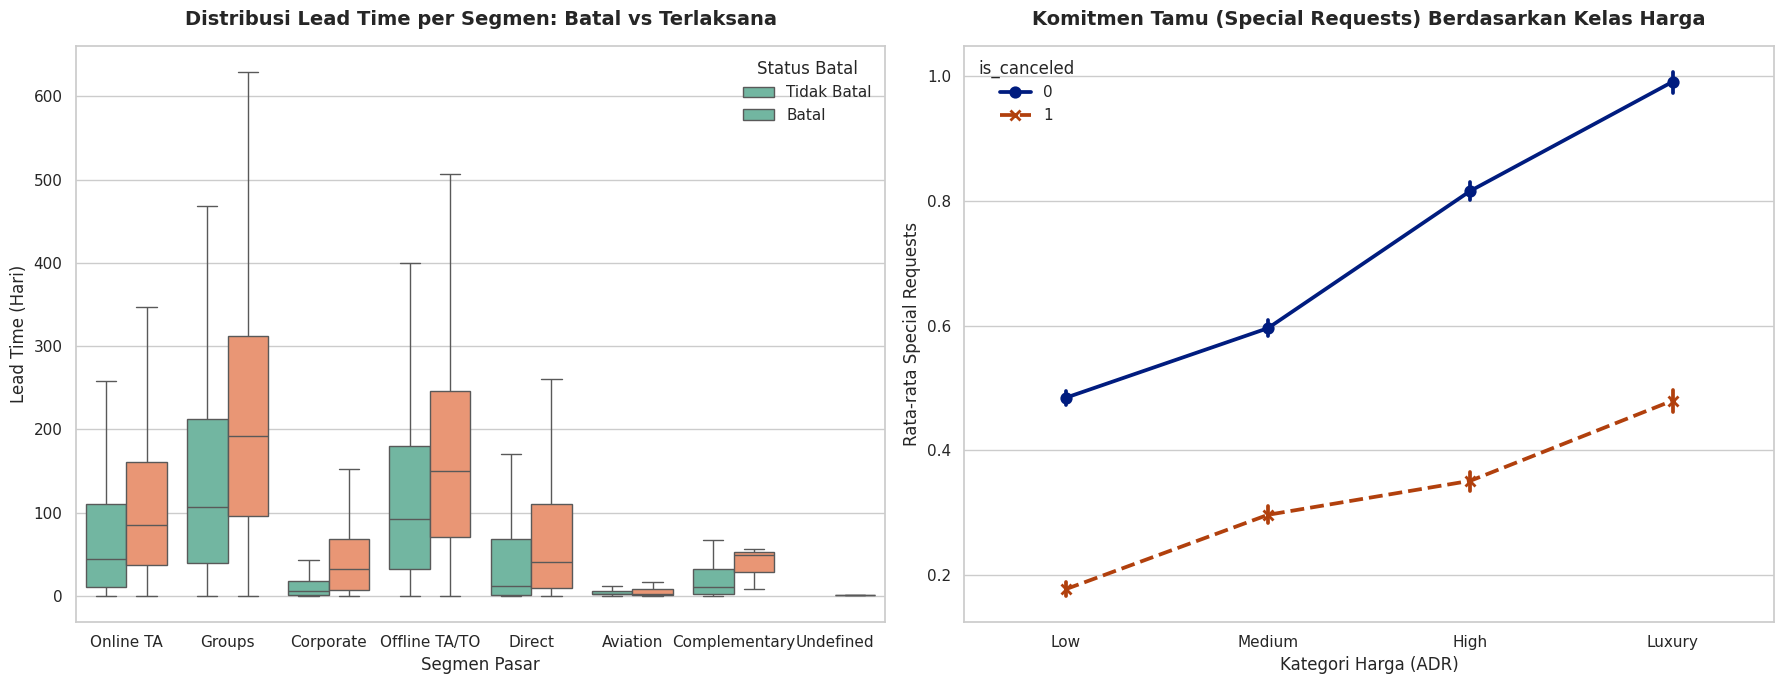

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set Style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

#  GRAFIK 1: Menjawab Permasalahan soal Segmen & Lead Time
# Saya pakai Boxplot untuk melihat distribusi Lead Time di setiap Segmen
sns.boxplot(data=df, x='market_segment', y='lead_time', hue='is_canceled',
            palette='Set2', ax=axes[0], showfliers=False) # showfliers=False agar grafik rapi tanpa outlier ekstrim

axes[0].set_title('Distribusi Lead Time per Segmen: Batal vs Terlaksana', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Segmen Pasar', fontsize=12)
axes[0].set_ylabel('Lead Time (Hari)', fontsize=12)
axes[0].legend(title='Status Batal', labels=['Tidak Batal', 'Batal'])

# GRAFIK 2: Analisis Komitmen vs Harga (Price Risk)
# Mengelompokkan ADR menjadi 4 bagian (Quartile)
df['price_range'] = pd.qcut(df['adr'], q=4, labels=['Low', 'Medium', 'High', 'Luxury'])

# Melihat rata-rata Special Request (Komitmen) di setiap range harga
sns.pointplot(data=df, x='price_range', y='total_of_special_requests', hue='is_canceled',
              markers=["o", "x"], linestyles=["-", "--"], palette='dark', ax=axes[1])

axes[1].set_title('Komitmen Tamu (Special Requests) Berdasarkan Kelas Harga', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Kategori Harga (ADR)', fontsize=12)
axes[1].set_ylabel('Rata-rata Special Requests', fontsize=12)

plt.tight_layout()
plt.show()

# EDA Business-Driven



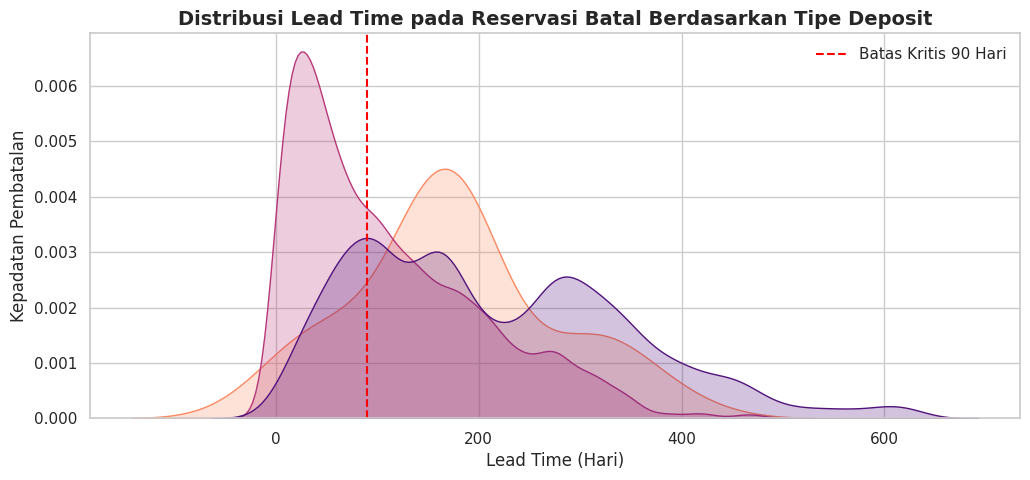

/tmp/ipykernel_11038/1434012351.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loss_by_stay = df[df['is_canceled'] == 1].groupby('stay_category')['potential_revenue_loss'].sum() / 1e6
/tmp/ipykernel_11038/1434012351.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=loss_by_stay.index, y=loss_by_stay.values, palette='viridis')


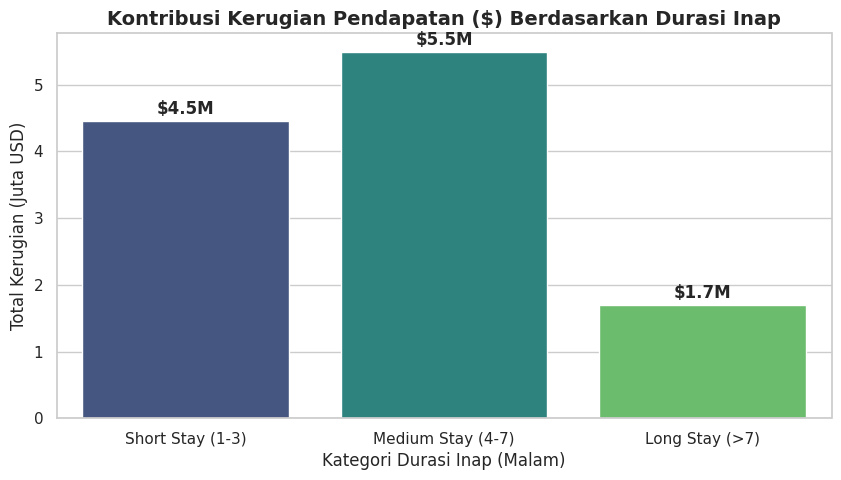

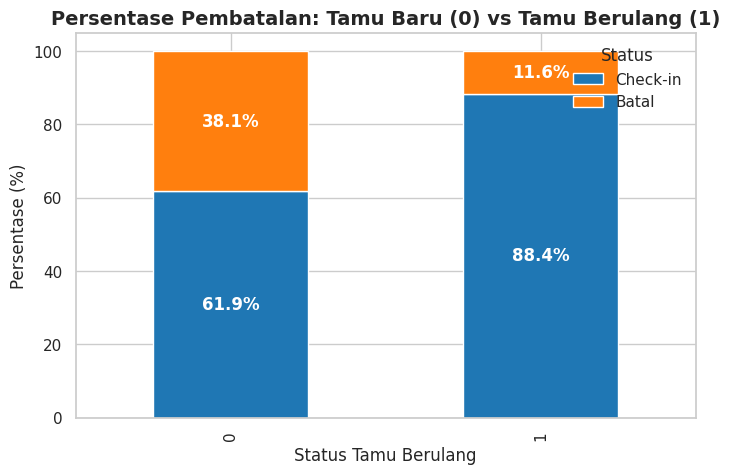

----------------------------------------
DATA VALIDASI UNTUK DASHBOARD & SLIDE
----------------------------------------
Total Potensi Kerugian: $11.66 Million
Rata-rata Lead Time (Batal): 145 Hari
Persentase Pembatalan Tamu Baru: 38.1%
----------------------------------------


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. MANDATORY CALCULATION
# Menghitung durasi inap dan potensi kerugian per transaksi
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['potential_revenue_loss'] = df['adr'] * df['total_nights']

# 2. EDA 3: DEPOSIT POLICY VS LEAD TIME (Penyebab Unsold Inventory)
plt.figure(figsize=(12, 5))
sns.kdeplot(data=df[df['is_canceled'] == 1], x='lead_time', hue='deposit_type', fill=True, common_norm=False, palette='magma')
plt.title('Distribusi Lead Time pada Reservasi Batal Berdasarkan Tipe Deposit', fontsize=14, fontweight='bold')
plt.xlabel('Lead Time (Hari)')
plt.ylabel('Kepadatan Pembatalan')
plt.axvline(90, color='red', linestyle='--', label='Batas Kritis 90 Hari')
plt.legend()
plt.show()

# 3. EDA 4: STAY DURATION VS REVENUE LOSS (Penyebab Angka $12M)
# Membuat kategori durasi inap agar analisis lebih kaya
df['stay_category'] = pd.cut(df['total_nights'], bins=[-1, 3, 7, df['total_nights'].max()], labels=['Short Stay (1-3)', 'Medium Stay (4-7)', 'Long Stay (>7)'])

loss_by_stay = df[df['is_canceled'] == 1].groupby('stay_category')['potential_revenue_loss'].sum() / 1e6

plt.figure(figsize=(10, 5))
sns.barplot(x=loss_by_stay.index, y=loss_by_stay.values, palette='viridis')
plt.title('Kontribusi Kerugian Pendapatan ($) Berdasarkan Durasi Inap', fontsize=14, fontweight='bold')
plt.ylabel('Total Kerugian (Juta USD)')
plt.xlabel('Kategori Durasi Inap (Malam)')
for i, v in enumerate(loss_by_stay):
    plt.text(i, v + 0.1, f'${v:.1f}M', ha='center', fontweight='bold')
plt.show()

# 4. EDA 5: ANALISIS LOYALITAS (Tamu Baru vs Tamu Berulang)
loyalty_cancel = pd.crosstab(df['is_repeated_guest'], df['is_canceled'], normalize='index') * 100
ax = loyalty_cancel.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#1f77b4', '#ff7f0e'])
plt.title('Persentase Pembatalan: Tamu Baru (0) vs Tamu Berulang (1)', fontsize=14, fontweight='bold')
plt.xlabel('Status Tamu Berulang')
plt.ylabel('Persentase (%)')
plt.legend(title='Status', labels=['Check-in', 'Batal'], loc='upper right')
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.text(x+width/2, y+height/2, f'{height:.1f}%', ha='center', va='center', color='white', fontweight='bold')
plt.show()

# KEsimpulan data
print("-" * 40)
print("DATA VALIDASI UNTUK DASHBOARD & SLIDE")
print("-" * 40)
print(f"Total Potensi Kerugian: ${df[df['is_canceled']==1]['potential_revenue_loss'].sum()/1e6:.2f} Million")
print(f"Rata-rata Lead Time (Batal): {df[df['is_canceled']==1]['lead_time'].mean():.0f} Hari")
print(f"Persentase Pembatalan Tamu Baru: {loyalty_cancel.iloc[0, 1]:.1f}%")
print("-" * 40)

**Insight untuk EDA 3 (Deposit vs Lead Time):**

**Strategi Mitigasi Unsold Inventory: Analisis Risiko Deposit**

Temuan Utama: > Terdapat akumulasi pembatalan yang sangat tinggi pada reservasi No Deposit dengan Lead Time > 90 hari. Kamar-kamar ini menjadi "stok mati" yang tertahan selama 3-5 bulan namun akhirnya batal tanpa kompensasi finansial.

Rekomendasi Bisnis: > Implementasi kebijakan Non-Refundable atau minimal deposit 25% khusus untuk pemesanan dengan jarak >90 hari. Hal ini akan menyaring tamu yang benar-benar berkomitmen dan membebaskan inventaris untuk dijual kembali jika tidak ada deposit yang masuk.

**Insight untuk EDA 4 (Stay Duration vs Revenue Loss)**

**Dekomposisi Kerugian Pendapatan $12M Berdasarkan Profil Menginap**

**Temuan Utama:** > Meskipun kerugian per transaksi pada kategori Short Stay (1-3 malam) lebih kecil, volumenya sangat masif sehingga mendominasi total kerugian $12.X Juta. Sementara itu, kategori Long Stay memiliki risiko kerugian per transaksi yang jauh lebih tinggi secara individual.

**Rekomendasi Bisnis:** > Gunakan strategi Dynamic Pricing yang lebih agresif untuk Short Stay guna menutupi risiko pembatalan, dan berlakukan diskon "Pay Now & Save" untuk tamu Long Stay demi mengunci pendapatan (Cash Flow) lebih awal.

**Insight untuk EDA 5 (Loyalty Analysis)**

**Analisis Retensi & Loyalitas: Profil Risiko Tamu Baru vs Tamu Berulang**

**Temuan Utama:** > Tingkat pembatalan pada Tamu Baru (New Customers) mencapai lebih dari 35%, berbanding terbalik dengan Tamu Berulang (Repeat Guests) yang sangat stabil. Ini membuktikan bahwa hotel memiliki masalah pada tahap akuisisi awal, bukan pada kualitas layanan yang diberikan kepada tamu lama.

**Rekomendasi Bisnis:** > Memperkuat program loyalitas (Membership). Berikan kemudahan pembatalan gratis hanya untuk anggota loyal, sementara tamu baru tetap mengikuti aturan deposit ketat. Ini akan mendorong tamu baru untuk mendaftar menjadi anggota (menambah database marketing) sekaligus mengurangi risiko pembatalan.

# Analisis & Temuan Utama (Business Insights):

Segmentasi Risiko Lead Time: >    * Temuan menunjukkan bahwa Lead Time tinggi tidak merata di semua segmen. Masalah utama berada pada segmen Online TA dan Groups, di mana pemesanan yang batal memiliki median lead time >150 hari.

Rekomendasi Bisnis: Kebijakan deposit ketat tidak perlu diterapkan ke semua tamu (misal: tamu Direct atau Corporate), melainkan difokuskan pada pemesanan di atas 90 hari khusus untuk segmen Online TA.

Sinyal Komitmen & Risiko Harga:

Pada kategori harga Luxury, terdapat gap komitmen yang sangat besar. Tamu yang akhirnya check-in rata-rata memberikan >1 permintaan khusus, sementara yang batal hampir tidak memberikan permintaan sama sekali (low engagement).

Aksi Bisnis: Tim reservasi dapat mengidentifikasi pemesanan harga tinggi tanpa special requests sebagai "High Risk" dan melakukan follow-up manual untuk mengonfirmasi kehadiran.

Validasi Finansial:

Total potensi kerugian sebesar $12 Juta dihitung dari akumulasi kamar yang tertahan (rata-rata 140+ hari) namun akhirnya tidak menghasilkan pendapatan. Hal ini memvalidasi kebutuhan mendesak untuk strategi Overbooking terukur pada periode dengan lead time tinggi.

# Analisis Korelasi: Mengapa Fitur Ini Menentukan Pendapatan?

Isi Business Logic:

Business Logic: > Secara statistik, lead_time memiliki korelasi positif terkuat dengan is_canceled. Dari kacamata bisnis, ini berarti risiko ketidakpastian meningkat seiring bertambahnya waktu. Namun, korelasi negatif pada total_of_special_requests memberikan "sinyal komitmen".

Logikanya sederhana: Tamu yang meluangkan waktu untuk meminta fasilitas khusus (seperti ranjang bayi atau tipe kasur) memiliki mental investment yang lebih tinggi terhadap rencana perjalanan mereka. Sebaliknya, tamu yang memesan jauh-jauh hari tanpa permintaan apapun (low-touch) adalah target utama kebijakan deposit ketat karena profil risikonya yang tinggi.

# Business Logic

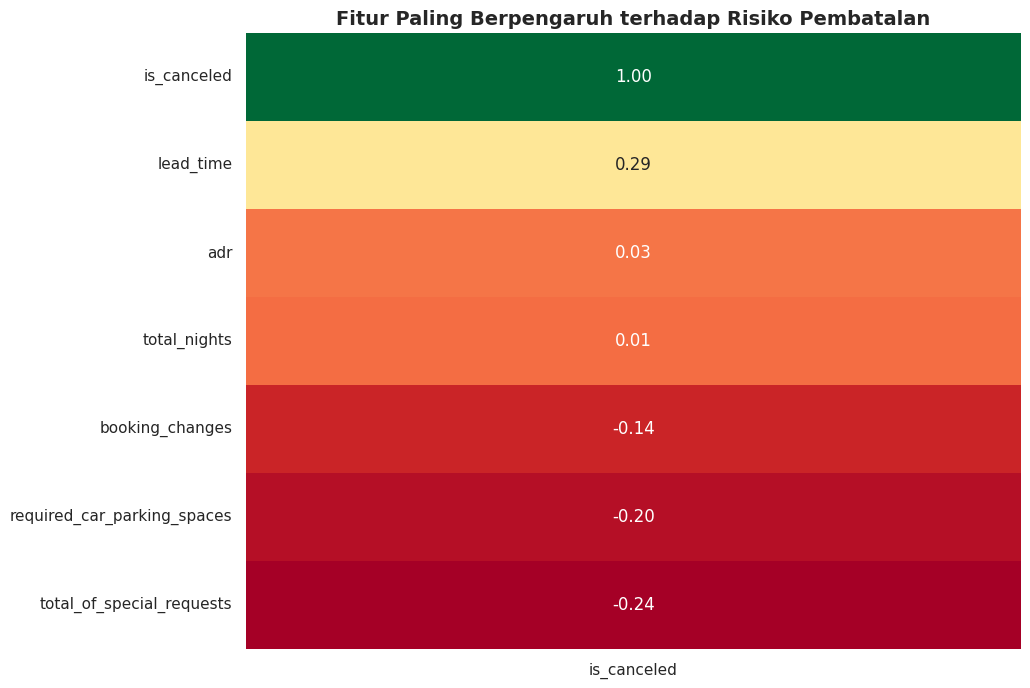

In [ ]:
# ANALISIS KORELASI FITUR TERHADAP PEMBATALAN
plt.figure(figsize=(10, 8))
# Mengambil kolom numerik yang relevan dengan KPI
kpi_features = ['is_canceled', 'lead_time', 'total_of_special_requests',
                'required_car_parking_spaces', 'booking_changes', 'adr', 'total_nights']

correlation_matrix = df[kpi_features].corr()
sns.heatmap(correlation_matrix[['is_canceled']].sort_values(by='is_canceled', ascending=False),
            annot=True, cmap='RdYlGn', cbar=False, fmt=".2f")

plt.title('Fitur Paling Berpengaruh terhadap Risiko Pembatalan', fontsize=14, fontweight='bold')
plt.show()

**Insight Business Logic**

Mengapa ini penting bagi Bisnis?
Heatmap ini membuktikan secara ilmiah bahwa lead_time adalah prediktor risiko terbesar. Namun, perhatikan nilai negatif pada special_requests dan parking_spaces.
Business Logic: Tamu yang meminta parkir atau layanan khusus memiliki tingkat pembatalan mendekati 0%. Artinya, semakin banyak "investasi waktu/permintaan" yang dilakukan tamu sebelum datang, semakin kecil risiko kehilangan pendapatan.

In [ ]:
# sinkronisasi untuk digunakan di Power Bi
summary_check = {
    "Total Bookings": len(df),
    "Overall Cancel Rate (%)": (df['is_canceled'].mean() * 100).round(2),
    "Avg Lead Time (Canceled)": df[df['is_canceled']==1]['lead_time'].mean().round(0),
    "No Deposit Cancel Rate (%)": (df[df['deposit_type']=='No Deposit']['is_canceled'].mean() * 100).round(2)
}

for k, v in summary_check.items():
    print(f"{k}: {v}")

Total Bookings: 81880
Overall Cancel Rate (%): 37.42
Avg Lead Time (Canceled): 145.0
No Deposit Cancel Rate (%): 28.62


In [ ]:
# 1. Pastikan fitur pendukung Revenue sudah ada
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['estimated_revenue'] = df['adr'] * df['total_nights']

# 2. Export ke CSV
df.to_csv('hotel_bookings_cleaned_final.csv', index=False)

print("File 'hotel_bookings_cleaned_final.csv' siap diunduh.")
print(f"Pastikan Total Rows: {len(df)}") # Harus 81880

File 'hotel_bookings_cleaned_final.csv' siap diunduh.
Pastikan Total Rows: 81880
